<a href="https://colab.research.google.com/github/SalvadorCM786/modulo3-prediccion-de-enfermedad-cardiaca-ml/blob/main/modulo3_prediccion_de_enfermedad_cardiaca_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# Heart Disease Prediction

## Proyecto de Machine Learning

## Este proyecto tiene como objetivo construir un modelo de aprendizaje automático supervisado para predecir la presencia de enfermedad cardíaca en pacientes, utilizando un dataset clínico cargado desde Google Drive.

## El problema corresponde a una tarea de clasificación binaria, donde la variable objetivo indica si una persona presenta o no enfermedad cardíaca.

In [10]:
# ==============================
# Importación de librerías
# ==============================

# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Métricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

In [11]:
# ==============================
# Carga del dataset desde Google Drive
# ==============================

import pandas as pd

# Ejemplo de enlace:
# https://drive.google.com/file/d/LO-QUE-ESTA-AQUI-ES-EL-IDENTIFICADOR/view?usp=sharing

file_id = "1ch-he5nfIQyue1eM8ZCEUX0LS8vsn4PY"

# URL de descarga directa
url = f"https://drive.google.com/uc?export=download&id={file_id}"

# Cargar dataset
df = pd.read_csv(url)

# Mostrar las primeras filas
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [12]:
# ==============================
# Exploración inicial del dataset
# ==============================

print("Primeras filas del dataset:")
display(df.head())

print("\nTamaño del dataset:")
print(df.shape)

print("\nInformación general:")
df.info()

print("\nEstadísticas descriptivas:")
display(df.describe())

print("\nValores nulos por columna:")
display(df.isnull().sum())

Primeras filas del dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



Tamaño del dataset:
(1025, 14)

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Estadísticas descriptivas:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000



Valores nulos por columna:


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [13]:
# ==============================
# Columnas del dataset
# ==============================

print("Columnas del dataset:")
print(df.columns.tolist())

Columnas del dataset:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [14]:
# ==============================
# Definir variable objetivo
# ==============================

target_column = "target"

# Verificar que la columna exista
if target_column in df.columns:
    print(f"La variable objetivo es: {target_column}")
else:
    print("La columna 'target' no existe.")
    print("Columnas disponibles:")
    print(df.columns.tolist())

La variable objetivo es: target


Distribución de la variable objetivo:


target
1    526
0    499
Name: count, dtype: int64

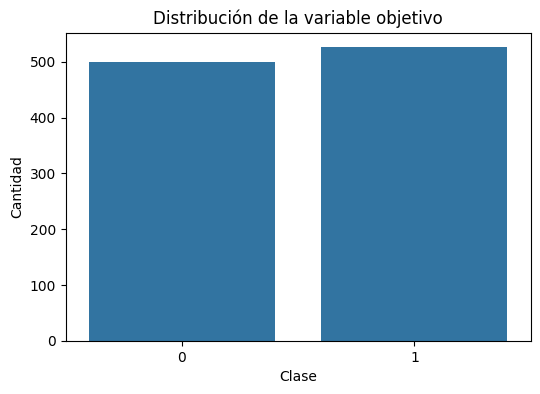

In [15]:
# ==============================
# Distribución de la variable objetivo
# ==============================

print("Distribución de la variable objetivo:")
display(df[target_column].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_column)
plt.title("Distribución de la variable objetivo")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()